# Paper figures drawn straight from result files: the evaluation (`eval.py`)

This notebook is the evaluation script `eval.py` from artifact **art_wqW6y0LsHO8g**. That artifact draws a deterministic set
of paper figures (F1-F7 plus an inferential-caveats table). It runs on CPU only, costs $0 and re-estimates nothing: every
plotted number is read from a hashed result file of an earlier artifact through one source registry (`sources.yaml`).

`eval.py` scores the finished figure set on seven metrics:

| metric | what it checks |
|---|---|
| **M1 value fidelity** | every plotted value matches its source file (exact, derived by a stated formula, or an image hash) |
| **M2 record drift** | numbers quoted in the research record, compared with the source files (MATCH / DRIFT / NOT_FOUND) |
| **M3 figure completeness** | each figure has a PDF, a PNG, `figure_spec.json`, a 2-4 sentence caption with N, CI and source, `plotted_values.json` and a passing check |
| **M4 request coverage** | which of the 8 requested activities has a figure |
| **M5 production** | width/height in mm, 600 dpi, min font size, no Type 3 fonts, no text overlaps |
| **M6 label integrity** | every row's evidence label is in the allowed set and agrees with the record |
| **M7 spend** | OpenRouter USD (0) |

**About the demo data.** The original script runs `checks/check_F*.py`, `production.py`, `drift.py` and the lint as
subprocesses. Those need the whole run tree: about 57 source files from other artifacts plus the rendered PDFs. This
notebook skips those runs. `mini_demo_data.json` holds their stored outputs (the `results/*.json` files) together with the
captions, labels, a varied subset of `plotted_values.json` rows and a subset of drift rows. The notebook writes these
into a small local workspace (`demo_ws/`) and then runs the original `eval.py` code on it. The metrics come out the same
as in the full run. Only the per-row example lists are shorter.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru - NOT on Colab, always install
_pip('loguru==0.7.3')

# matplotlib - pre-installed on Colab, install locally only (at Colab's version)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

## Imports
This is the original import block of `eval.py`. The original also imports `run_figure` from `checks/independent.py`,
which is never called, and `src.style`, which is used only for the two figure widths. Neither module is in the demo
bundle, so `style` is rebuilt from the data below. `matplotlib` is added for the summary plots.

In [2]:
from __future__ import annotations

import csv
import json
import re
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions ---
from types import SimpleNamespace
import matplotlib.pyplot as plt

## Data loading helper
The data is fetched from GitHub, with the local `mini_demo_data.json` as a fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_aMfESsKemlKH/round-5/evaluation-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("figures in bundle:", list(data["figures"]))
print("stored result files:", list(data["results"]))

figures in bundle: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F6b', 'F7']
stored result files: ['check_F1.json', 'check_F2.json', 'check_F3.json', 'check_F4.json', 'check_F5.json', 'check_F6.json', 'check_F6b.json', 'check_F7.json', 'check_caveats.json', 'check_selftest.json', 'production_checks.json', 'lint_no_literals.json', 'drift_summary.json', 'drift_report_rows', 'n_drift_rows_full']


## Config
The metrics come from the stored check summaries, so they do not change with these settings. The two parameters only
limit how many per-row examples are written into the demo workspace and so appear in the per-row lists of `eval_out.json`.
- `MAX_PV_ROWS_PER_FIGURE`: plotted-value rows per figure. The bundle holds up to 9 per figure; the full run has
  957 plotted values plus 29 caveat-table values.
- `MAX_DRIFT_ROWS`: drift-report rows. The bundle holds 24 (all 4 DRIFT/NOT_FOUND rows plus 20 MATCH rows); the full
  run has 174.

In [5]:
MAX_PV_ROWS_PER_FIGURE = 9   # bundle max 9  (original full run: all rows, 957 plotted values in total)
MAX_DRIFT_ROWS = 24           # bundle max 24 (original full run: 174 record quotes)
WS = Path("demo_ws").resolve()   # stands in for the artifact directory (Path(__file__).resolve().parent)

## Rebuild the workspace layout that `eval.py` reads
This cell is new. It writes the bundled files to the paths `eval.py` expects:
`results/check_*.json`, `results/{production_checks,lint_no_literals,drift_summary}.json`, `results/drift_report.csv`,
`figures/<F>/{caption.md,labels.json,plotted_values.json}` and `tables/caveats_{labels,values}.json`.
The completeness metric (M3) checks only whether the PDF, PNG and `figure_spec.json` files exist. For those, the cell
writes empty placeholder files with the original names; the real figures are several MB each. `style` gets the two
figure widths.

In [6]:
for sub in ("results", "figures", "tables", "logs"):
    (WS / sub).mkdir(parents=True, exist_ok=True)
res = data["results"]
for name, obj in res.items():
    if name.endswith(".json"):
        (WS / "results" / name).write_text(json.dumps(obj, indent=1))
drift_rows = res["drift_report_rows"][:MAX_DRIFT_ROWS]
with (WS / "results" / "drift_report.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(drift_rows[0]))
    w.writeheader()
    w.writerows(drift_rows)
for f, fd in data["figures"].items():
    d = WS / "figures" / f
    d.mkdir(exist_ok=True)
    for fn in fd["files"]:                      # placeholders for pdf / png / figure_spec / other binaries
        if fn not in ("caption.md", "labels.json", "plotted_values.json"):
            (d / fn).write_text("")
    if fd["caption.md"]:
        (d / "caption.md").write_text(fd["caption.md"])
    (d / "labels.json").write_text(json.dumps(fd["labels.json"]))
    (d / "plotted_values.json").write_text(json.dumps(fd["plotted_values.json"][:MAX_PV_ROWS_PER_FIGURE]))
(WS / "tables" / "caveats_labels.json").write_text(json.dumps(data["tables"]["caveats_labels.json"]))
(WS / "tables" / "caveats_values.json").write_text(
    json.dumps(data["tables"]["caveats_values.json"][:MAX_PV_ROWS_PER_FIGURE]))
style = SimpleNamespace(**data["style"])        # replaces `from src import style`
print("workspace written to", WS.name + "/")

workspace written to demo_ws/


## Logging and constants (original)
The logger is set up as in the original. `FIGS` are the seven main figures; `ALL_FIGS` adds the supplementary F6b.
`ALLOWED` is the fixed set of evidence labels, and `RECORD_MAP` maps the record's shorthand labels onto that set.
`COVERAGE` is the hand-written map from each of the 8 requested research activities to the figure that shows it.

In [7]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

FIGS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7"]
ALL_FIGS = FIGS[:6] + ["F6b", "F7"]
ALLOWED = {"SCREEN", "CONFIRMATORY", "REPLICATION", "SUPPLEMENTARY/POOLED", "MECHANISM", "DESCRIPTIVE",
           "POST-CONFIRMATION EXPLORATORY"}
RECORD_MAP = {"SUPPLEMENTARY": "SUPPLEMENTARY/POOLED", "POOLED": "SUPPLEMENTARY/POOLED"}
COVERAGE = [
    ("1 semantic grounding (frame, classifier/linker, corpus)", "F1 band 1", "shown", ""),
    ("2 two network views (co-word snapshots; concept-subfield bipartite)", "F1 band 2; F6b ego/alluvial",
     "shown", "network layouts are embedded from exp_8 (supplementary)"),
    ("3 RQ1 structural precursors of emergence", "F4", "shown", "R1_DEAD stated on the figure"),
    ("4 RQ2 diffusion across disciplinary boundaries (host entry, grafting)", "F2, F3", "shown", ""),
    ("5 diffusion typology", "F5; F1 band 4", "shown", ""),
    ("6 case studies (quantitatively selected)", "F6; F6b", "shown", ""),
    ("7 methodology in graphical form", "F1", "shown", ""),
    ("8 comparison to related work", "none", "not shown",
     "a literature comparison is prose/table work for the paper step; no figure here"),
]

## M3: figure completeness (original)
`sentences()` counts caption sentences. It removes the leading "F2." tag and protects abbreviations such as "e.g."
first. `completeness()` then checks each main figure for a PDF, a PNG, `figure_spec.json`, `plotted_values.json` and a
passing check. The caption must have 2-4 sentences and state N (or a count), the CI type and a
`3_invention_loop/iter_k/gen_art/` source path. The score is the fraction of these boolean cells that are True.

In [8]:
def sentences(text: str) -> int:
    body = re.sub(r"^F\d+b?\s*(\(\w+\))?\.\s*", "", text.strip())
    body = re.sub(r"\b(e\.g|i\.e|et al|vs|cf)\.", "x", body)
    return len([s for s in re.split(r"(?<=[.!?])\s+(?=[A-Z(])", body) if s.strip()])


def completeness() -> tuple[list[dict], float]:
    rows = []
    for f in FIGS:
        d = WS / "figures" / f
        cap = (d / "caption.md").read_text() if (d / "caption.md").exists() else ""
        chk = json.loads((WS / "results" / f"check_{f}.json").read_text()) if (
            WS / "results" / f"check_{f}.json").exists() else {"n_failed": 1}
        n_s = sentences(cap)
        cap_ok = (2 <= n_s <= 4 and bool(re.search(r"\bn\s*=|\bN\s*=|\b\d[\d,]*\s+(concepts|entries|draws|cases|"
                                                      r"strata|pairs|papers|events)", cap))
                  and bool(re.search(r"CI|confidence|no CIs|per row", cap))
                  and bool(re.search(r"3_invention_loop/iter_\d/gen_art/", cap)))
        rows.append({"figure": f, "pdf": any(d.glob("*.pdf")), "png": any(d.glob("*.png")),
                     "figure_spec": (d / "figure_spec.json").exists(), "caption": cap_ok,
                     "plotted_values": (d / "plotted_values.json").exists(),
                     "check_passes": chk["n_failed"] == 0 and (WS / "checks" / f"check_{f}.py").exists(),
                     "caption_sentences": n_s})
    cells = [v for r in rows for k, v in r.items() if k not in ("figure", "caption_sentences")]
    return rows, sum(cells) / len(cells)

## M6: label integrity (original)
This function collects every labelled row from the figures and the caveats table. It counts a row as a mismatch when
its shown label is outside `ALLOWED`, or when the research record gives a label that, after `RECORD_MAP`, differs from
the shown one.

In [9]:
def label_integrity() -> dict:
    labs = []
    for f in ALL_FIGS:
        p = WS / "figures" / f / "labels.json"
        if p.exists():
            labs += json.loads(p.read_text())
    labs += json.loads((WS / "tables" / "caveats_labels.json").read_text())
    bad_set = [l for l in labs if l["shown"] not in ALLOWED]
    mism = [l for l in labs if l.get("record_label") and RECORD_MAP.get(l["record_label"], l["record_label"])
            != l["shown"]]
    n_rec = sum(1 for l in labs if l.get("record_label"))
    return {"n_rows": len(labs), "n_with_record_label": n_rec, "not_in_allowed_set": bad_set,
            "record_mismatches": mism, "label_mismatches": len(bad_set) + len(mism)}

## `main()` part 1: per-figure checks and auxiliary scripts
In the original, each `checks/check_<F>.py` runs as a subprocess and re-reads every plotted value from its hashed
source file. Then `production.py` (PDF geometry and fonts), `lint_no_literals.py` (no hard-coded numbers in the plot
code) and `drift.py` (record quotes against sources) run. All of them write JSON into `results/`, which `main()` reads
back. Those scripts need the full run tree, so the notebook comments out the `subprocess.run` lines and reads the JSON
outputs that the original run stored. The code that reads them is unchanged.

One side effect: `completeness()` also requires `checks/check_<F>.py` to exist. The demo writes the check scripts
as empty placeholders so that this condition behaves as it did in the original workspace.

In [10]:
# placeholder check scripts (see markdown above) - the real ones are in the artifact's checks/ directory
(WS / "checks").mkdir(exist_ok=True)
for f in ALL_FIGS + ["caveats"]:
    (WS / "checks" / f"check_{f}.py").write_text("")

logger.info("running per-figure checks")
checks = {}
for f in ALL_FIGS + ["caveats"]:
    # rc = subprocess.run([sys.executable, str(WS / "checks" / f"check_{f}.py")], capture_output=True, text=True)
    checks[f] = json.loads((WS / "results" / f"check_{f}.json").read_text())
    logger.info(f"check_{f}: n_values {checks[f]['n_values']} failed {checks[f]['n_failed']}")
# for script in ("production.py", "lint_no_literals.py", "drift.py"):
#     rc = subprocess.run([sys.executable, str(WS / "checks" / script)], capture_output=True, text=True)
#     logger.info(f"{script}: exit {rc.returncode}")
prod = json.loads((WS / "results" / "production_checks.json").read_text())
lint = json.loads((WS / "results" / "lint_no_literals.json").read_text())
drift = json.loads((WS / "results" / "drift_summary.json").read_text())
selftest = json.loads((WS / "results" / "check_selftest.json").read_text())
comp_rows, comp = completeness()
labels = label_integrity()

04:05:14|INFO   |running per-figure checks


04:05:14|INFO   |check_F1: n_values 39 failed 0


04:05:14|INFO   |check_F2: n_values 124 failed 0


04:05:14|INFO   |check_F3: n_values 163 failed 0


04:05:14|INFO   |check_F4: n_values 102 failed 0


04:05:14|INFO   |check_F5: n_values 67 failed 0


04:05:14|INFO   |check_F6: n_values 425 failed 0


04:05:14|INFO   |check_F6b: n_values 8 failed 0


04:05:14|INFO   |check_F7: n_values 0 failed 0


04:05:14|INFO   |check_caveats: n_values 29 failed 0


## `main()` part 2: aggregate the metrics (original)
This part sums the per-figure check counts into value fidelity, i.e. the share of plotted values that did not fail.
It writes the summary CSV and JSON files and builds `metrics_agg`.

In [11]:
n_val = sum(c["n_values"] for c in checks.values())
n_fail = sum(c["n_failed"] for c in checks.values())
fidelity = {"n_values": n_val, "n_exact": sum(c["n_exact"] for c in checks.values()),
            "n_derived": sum(c["n_derived"] for c in checks.values()),
            "n_images": sum(c["n_images"] for c in checks.values()), "n_failed": n_fail,
            "n_source_missing_not_plotted": sum(c["n_source_missing"] for c in checks.values()),
            "value_fidelity": (n_val - n_fail) / n_val if n_val else 0.0, "per_figure": checks}
(WS / "results" / "fidelity_summary.json").write_text(json.dumps(fidelity, indent=1, default=str))
with (WS / "results" / "figure_completeness.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(comp_rows[0]))
    w.writeheader()
    w.writerows(comp_rows)
with (WS / "results" / "request_coverage.csv").open("w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["activity", "figure_or_panel", "status", "reason"])
    w.writerows(COVERAGE)
(WS / "results" / "label_integrity.json").write_text(json.dumps(labels, indent=1, default=str))
metrics = {
    "value_fidelity": fidelity["value_fidelity"], "n_plotted_values": n_val, "n_exact": fidelity["n_exact"],
    "n_derived": fidelity["n_derived"], "n_images_hash_checked": fidelity["n_images"], "n_failed": n_fail,
    "n_source_missing_not_plotted": fidelity["n_source_missing_not_plotted"],
    "n_record_expectations": drift["n"], "n_match": drift["counts"]["MATCH"],
    "n_rounding_diff": drift["counts"]["ROUNDING_DIFF"], "n_drift": drift["counts"]["DRIFT"],
    "n_not_found": drift["counts"]["NOT_FOUND"], "figure_completeness": comp,
    "request_coverage_shown_fraction": sum(c[2] == "shown" for c in COVERAGE) / len(COVERAGE),
    "min_font_pt": min(p["min_font_pt"] for p in prod), "n_text_overlaps": sum(p["n_text_overlaps"] for p in prod),
    "production_pass_fraction": sum(p["pass"] for p in prod) / len(prod),
    "label_mismatches": labels["label_mismatches"], "lint_literal_hits": lint["n_hits"],
    "mutation_selftest_pass": float(selftest["selftest_pass"]), "openrouter_usd": 0.0,
}

## `main()` part 3: per-row examples and `eval_out.json` (original)
The script writes one example per plotted value. A value scores `eval_value_match` 0 if its check listed it as a
failure. It also writes one example per drift row and one per figure-completeness, coverage and production row. Together
with `metrics_agg` these go into `eval_out.json` (format `exp_eval_sol_out`).

In [12]:
ex_pv = []
for f in ALL_FIGS + ["caveats"]:
    p = (WS / "tables" / "caveats_values.json") if f == "caveats" else (WS / "figures" / f / "plotted_values.json")
    failed = {(x["panel"], x["row"], x["field"]) for x in checks[f]["failures"]}
    for r in json.loads(p.read_text()):
        if r.get("status") != "OK":
            continue
        ex_pv.append({"input": f"{r['figure']} | panel {r['panel']} | row {r['row']} | {r['field']}",
                      "output": str(r["value"]), "metadata_key": r["key"],
                      "metadata_source_path": r.get("path", ""), "metadata_artifact_id": r.get("artifact_id", ""),
                      "metadata_sha256": r.get("sha256", ""), "metadata_fold_label": r.get("fold_label", ""),
                      "metadata_ci_type": r.get("ci_type", ""), "metadata_source_kind": r.get("source_kind", ""),
                      "metadata_display_string": r.get("display_string") or "",
                      "predict_figure": str(r["value"]),
                      "eval_value_match": 0.0 if (r["panel"], r["row"], r["field"]) in failed else 1.0})
ex_drift = []
for r in csv.DictReader((WS / "results" / "drift_report.csv").open()):
    ex_drift.append({"input": f"record quote {r['key']}: {r['quoted']}", "output": r["source_value"] or "NOT_FOUND",
                     "metadata_status": r["status"], "metadata_source": r["source"],
                     "metadata_note": r["note"], "predict_record": r["quoted"],
                     "eval_match": 1.0 if r["status"] == "MATCH" else 0.0})
ex_comp = [{"input": f"figure {r['figure']} deliverables", "output": json.dumps(r),
            "predict_complete": str(all(v for k, v in r.items() if k not in ("figure", "caption_sentences"))),
            "eval_complete": float(all(v for k, v in r.items() if k not in ("figure", "caption_sentences")))}
           for r in comp_rows]
ex_cov = [{"input": a, "output": f"{fp} ({st})", "metadata_reason": rsn, "predict_status": st,
           "eval_shown": 1.0 if st == "shown" else 0.0} for a, fp, st, rsn in COVERAGE]
ex_prod = [{"input": f"production {p['figure']}", "output": "PASS" if p["pass"] else "FAIL",
            "predict_check": "PASS" if p["pass"] else "FAIL",
            "metadata_detail": json.dumps({k: v for k, v in p.items() if k != "colourblind"}),
            "eval_pass": float(p["pass"]), "eval_min_font_pt": float(p["min_font_pt"])} for p in prod]
out = {"metadata": {"evaluation_name": "paper figure set drawn straight from result files",
                    "artifact_plan": "gen_plan_evaluation_4_idx5",
                    "description": "Fidelity, drift, completeness, coverage, production and label checks for "
                                   "figures F1-F7 and the inferential caveats table; nothing re-estimated.",
                    "figure_widths_mm": [style.W_DOUBLE_MM, style.W_SINGLE_MM]},
       "metrics_agg": metrics,
       "datasets": [{"dataset": "plotted_values", "examples": ex_pv}, {"dataset": "drift", "examples": ex_drift},
                    {"dataset": "figure_completeness", "examples": ex_comp},
                    {"dataset": "request_coverage", "examples": ex_cov},
                    {"dataset": "production_checks", "examples": ex_prod}]}
(WS / "eval_out.json").write_text(json.dumps(out, indent=1, default=str))
logger.info(json.dumps(metrics))

04:05:15|INFO   |{"value_fidelity": 1.0, "n_plotted_values": 957, "n_exact": 939, "n_derived": 10, "n_images_hash_checked": 8, "n_failed": 0, "n_source_missing_not_plotted": 9, "n_record_expectations": 174, "n_match": 170, "n_rounding_diff": 0, "n_drift": 3, "n_not_found": 1, "figure_completeness": 1.0, "request_coverage_shown_fraction": 0.875, "min_font_pt": 6.5, "n_text_overlaps": 0, "production_pass_fraction": 1.0, "label_mismatches": 0, "lint_literal_hits": 0, "mutation_selftest_pass": 1.0, "openrouter_usd": 0.0}


## Results
The table lists the aggregate metrics. The figures show the plotted values checked per figure, the drift status of the
174 record quotes, figure completeness and the production checks. The drift rows printed after them are the corrections
the paper step has to make.

metric                                 value
--------------------------------------------
value_fidelity                         1.000
n_plotted_values                         957
n_exact                                  939
n_derived                                 10
n_images_hash_checked                      8
n_failed                                   0
n_source_missing_not_plotted               9
n_record_expectations                    174
n_match                                  170
n_rounding_diff                            0
n_drift                                    3
n_not_found                                1
figure_completeness                    1.000
request_coverage_shown_fraction        0.875
min_font_pt                            6.500
n_text_overlaps                            0
production_pass_fraction               1.000
label_mismatches                           0
lint_literal_hits                          0
mutation_selftest_pass                 1.000
openrouter

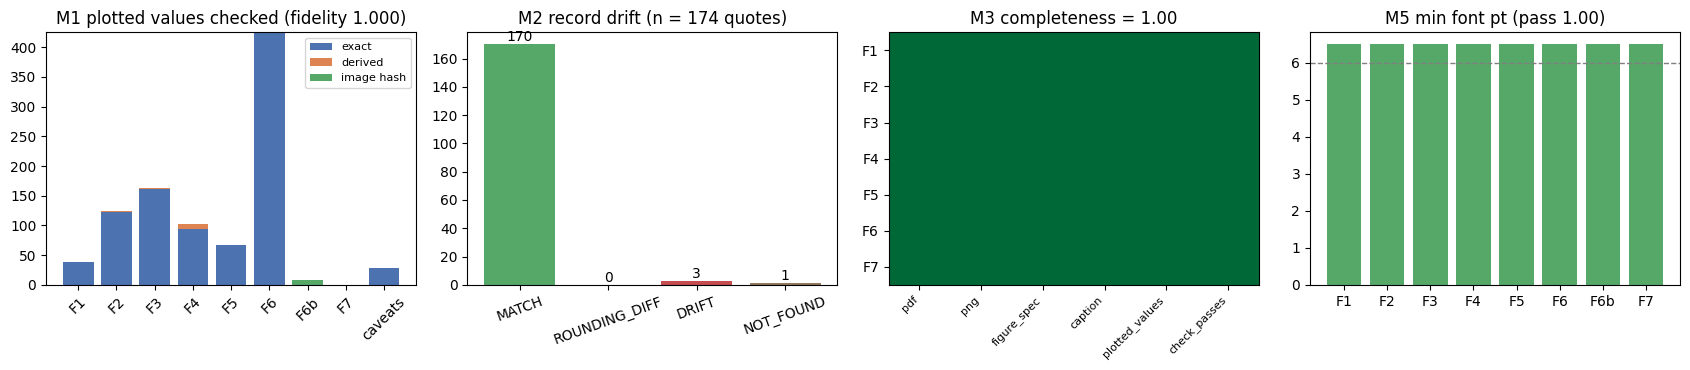


DRIFT / NOT_FOUND record quotes (corrections for the paper step):
  [DRIFT] d2_screen_entries_d2events: quoted 1,740 vs source 1746.0 - same quoted number vs d2_summary events MAIN_kw5 screen
  [DRIFT] robust_old_claim_sig: quoted 26 vs source 20.0 - iteration-4 review: '26 of 27' was wrong
  [NOT_FOUND] single_paper_1344: quoted 1,344 vs source None - '1344 of 1544 single-paper' - no source file contains this count
  [DRIFT] f1_substrate_edges_84k: quoted 84000 vs source 98514.0 - about 84k edges: F1 prints the 2023 snapshot (98514 kept edges); 84k matches the median kept edges over 2000-2024 (83875) - record should say which


In [13]:
print(f"{'metric':<34}{'value':>10}")
print("-" * 44)
for k, v in metrics.items():
    print(f"{k:<34}{(f'{v:.3f}' if isinstance(v, float) else str(v)):>10}")
print("\nexamples per dataset in eval_out.json:", {d["dataset"]: len(d["examples"]) for d in out["datasets"]})

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
figs = list(checks)
ax[0].bar(figs, [checks[f]["n_exact"] for f in figs], label="exact", color="#4C72B0")
ax[0].bar(figs, [checks[f]["n_derived"] for f in figs], bottom=[checks[f]["n_exact"] for f in figs],
          label="derived", color="#DD8452")
ax[0].bar(figs, [checks[f]["n_images"] for f in figs],
          bottom=[checks[f]["n_exact"] + checks[f]["n_derived"] for f in figs], label="image hash", color="#55A868")
ax[0].set_title(f"M1 plotted values checked (fidelity {metrics['value_fidelity']:.3f})")
ax[0].tick_params(axis="x", rotation=45); ax[0].legend(fontsize=8)
st = drift["counts"]
ax[1].bar(list(st), list(st.values()), color=["#55A868", "#8172B2", "#C44E52", "#937860"])
for i, v in enumerate(st.values()):
    ax[1].text(i, v, str(v), ha="center", va="bottom")
ax[1].set_title(f"M2 record drift (n = {drift['n']} quotes)")
ax[1].tick_params(axis="x", rotation=20)
keys = [k for k in comp_rows[0] if k not in ("figure", "caption_sentences")]
ax[2].imshow([[float(r[k]) for k in keys] for r in comp_rows], cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax[2].set_xticks(range(len(keys)), keys, rotation=45, ha="right", fontsize=8)
ax[2].set_yticks(range(len(comp_rows)), [r["figure"] for r in comp_rows])
ax[2].set_title(f"M3 completeness = {comp:.2f}")
ax[3].bar([p["figure"] for p in prod], [p["min_font_pt"] for p in prod],
          color=["#55A868" if p["pass"] else "#C44E52" for p in prod])
ax[3].axhline(6, ls="--", c="grey", lw=1)
ax[3].set_title(f"M5 min font pt (pass {metrics['production_pass_fraction']:.2f})")
plt.tight_layout(); plt.show()

print("\nDRIFT / NOT_FOUND record quotes (corrections for the paper step):")
for r in drift["drift_and_not_found"]:
    print(f"  [{r['status']}] {r['key']}: quoted {r['quoted']} vs source {r['source_value']} - {r['note']}")